# Fig2: zRatio sweep, raw_wbi vs map_wbi

Three stages:
1. Generate simulation.
2. Run raw_wbi and map_wbi.
3. Evaluate intensity RMSE.

The slice rule is z_slices = [10-zRatio, 10, 10+zRatio]. Thus zRatio=1 gives [9,10,11] and zRatio=2 gives [8,10,12].

The simulation is generated once per repetition and reused across zRatio values, so the deformation and noise realization are paired across the sweep.

The existing f2013 input used by the current Fig2 notebooks has 19 z planes (indices 0..18). Therefore zRatio=9 and zRatio=10 need an input with at least 20/21 z planes. The notebook validates this and stops instead of silently clipping the requested slices.

## Setup and fixed parameters

In [1]:
import json
import sys
import time
from pathlib import Path

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile

FIG2_ROOT = Path("/home/cyf/wbi/Virginia/code_for_paper/Fig2")
EXP_ROOT = FIG2_ROOT / "2.12_zRatio_sweep"
SIM_ROOT = EXP_ROOT / "simulation"
ALG_ROOT = EXP_ROOT / "algorithm_outputs"
RESULT_ROOT = EXP_ROOT / "results"

RAW_DATA_PATH = Path(
    "/home/cyf/wbi/Virginia/raw_data/f2013/"
    "250705_f2013_ubi_gcamp7f_bactin_mcherry_6dpf_15846.nd2"
)
SRC_ROOT = Path(
    "/home/cyf/wbi/Virginia/code_for_paper/"
    "wholistic_registration/src/wholistic_registration"
)
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from utils import calFlow3d_Wei_v1
from utils import calFlowCrossResolution
from utils import preprocess as prep
from utils.IO import readND2Frame
from utils.simulation import generateMotion_Biophysical

CUDA_DEVICE = 1
cp.cuda.Device(CUDA_DEVICE).use()

Z_RATIOS = list(range(1, 9))
N_REPS = 10
BASE_SEED = 20260825
Z_CENTER = 10

# Existing Fig2 simulation defaults.
DEFAULT_ART_R_XY = 120.0
DEFAULT_AMP_XY = 8.0
DEFAULT_NOISE_LEVEL = 1.0
DEFAULT_PHYSICAL_Z_RATIO = 3.0769230769230766

# Existing Fig2 WBI defaults.
DEFAULT_WBI_R = 5
WBI_LAYER = 3
WBI_ITER = 10
WBI_SMOOTH_PENALTY_RAW = 0.03
WBI_MOV_RANGE = 10.0
XY_CROP = 50

SAVE_REGISTERED_OUTPUTS = True

for directory in [SIM_ROOT, ALG_ROOT, RESULT_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)

print("Experiment root:", EXP_ROOT)
print("Raw data:", RAW_DATA_PATH)
print("zRatios:", Z_RATIOS, "repetitions:", N_REPS)
print("GPU device:", CUDA_DEVICE)



Experiment root: /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.12_zRatio_sweep
Raw data: /home/cyf/wbi/Virginia/raw_data/f2013/250705_f2013_ubi_gcamp7f_bactin_mcherry_6dpf_15846.nd2
zRatios: [1, 2, 3, 4, 5, 6, 7, 8] repetitions: 10
GPU device: 1


## 1. Generate simulation

The clean reference is saved once. Each repetition saves a noisy moving volume and its ground-truth motion field under simulation/repXX/.

In [2]:
def to_numpy(x):
    if hasattr(x, "get"):
        x = x.get()
    return np.asarray(x)


def make_z_slices(z_ratio, z_center=Z_CENTER, n_z=None):
    z_slices = np.array(
        [z_center - z_ratio, z_center, z_center + z_ratio],
        dtype=np.int32,
    )
    if n_z is not None and (z_slices.min() < 0 or z_slices.max() >= n_z):
        raise ValueError(
            f"zRatio={z_ratio} requests z_slices={z_slices.tolist()}, "
            f"but reference has {n_z} z planes; valid indices are 0..{n_z - 1}."
        )
    return z_slices


reference = readND2Frame(str(RAW_DATA_PATH), 0, channel=1)
reference = np.asarray(reference).squeeze().transpose(2, 1, 0).astype(np.float32)
if reference.ndim != 3:
    raise ValueError(f"Expected a 3D reference volume, got {reference.shape}")

reference_path = SIM_ROOT / "reference.tif"
if not reference_path.exists():
    tifffile.imwrite(reference_path, reference, bigtiff=True)
    print("Saved shared reference:", reference_path)
    
n_x, n_y, n_z = reference.shape
print("Reference shape (X,Y,Z):", reference.shape)

for z_ratio in Z_RATIOS:
    make_z_slices(z_ratio, n_z=n_z)



for rep_idx in range(1, N_REPS + 1):
    rep_dir = SIM_ROOT / f"rep{rep_idx:02d}"
    rep_dir.mkdir(parents=True, exist_ok=True)

    seed = BASE_SEED + rep_idx
    np_rng = np.random.default_rng(seed)
    cp.random.seed(seed)

    print(f"Generate rep {rep_idx:02d}/{N_REPS}, seed={seed}")
    motion = generateMotion_Biophysical(
        reference.shape,
        art_R_xy=DEFAULT_ART_R_XY,
        amp_xy=DEFAULT_AMP_XY,
        zRatio=DEFAULT_PHYSICAL_Z_RATIO,
        use_incompressibility=True,
    )
    motion = np.asarray(motion, dtype=np.float32)

    mov_clean = calFlow3d_Wei_v1.correctMotion(reference, motion)
    mov_clean = to_numpy(mov_clean).astype(np.float32, copy=False)
    noise = np_rng.normal(
        0.0, DEFAULT_NOISE_LEVEL, size=reference.shape
    ).astype(np.float32)
    mov_noisy = (mov_clean + noise).astype(np.float32)

    tifffile.imwrite(rep_dir / "mov.tif", mov_noisy, bigtiff=True)
    tifffile.imwrite(rep_dir / "motion.tif", motion, bigtiff=True)

    params = {
        "seed": int(seed),
        "simulation_art_R_xy": DEFAULT_ART_R_XY,
        "simulation_amp_xy": DEFAULT_AMP_XY,
        "simulation_noise_level": DEFAULT_NOISE_LEVEL,
        "simulation_physical_zRatio": DEFAULT_PHYSICAL_Z_RATIO,
        "reference_shape_XYZ": list(reference.shape),
        "reference_path": str(reference_path),
    }
    with open(rep_dir / "params.json", "w", encoding="utf-8") as f:
        json.dump(params, f, indent=2)

print("Simulation stage completed.")

Saved shared reference: /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.12_zRatio_sweep/simulation/reference.tif
Reference shape (X,Y,Z): (1152, 1152, 19)
Generate rep 01/10, seed=20260826
Generate rep 02/10, seed=20260827
Generate rep 03/10, seed=20260828
Generate rep 04/10, seed=20260829
Generate rep 05/10, seed=20260830
Generate rep 06/10, seed=20260831
Generate rep 07/10, seed=20260832
Generate rep 08/10, seed=20260833
Generate rep 09/10, seed=20260834
Generate rep 10/10, seed=20260835
Simulation stage completed.


## 2. Run raw_wbi and map_wbi

raw_wbi uses calFlow3d_Wei_v1.getMotion with sparse reference/moving planes.
map_wbi uses calFlowCrossResolution.getMotion_v2 with sparse moving planes and the full reference stack.
Registered three-plane outputs are saved under algorithm_outputs/repXX/zRatioYY/.

In [3]:
def build_wbi_option(ref_full, mov_sparse, sparse_z_ratio):
    option = {
        "zRatio": DEFAULT_PHYSICAL_Z_RATIO * sparse_z_ratio,
        "zRatio_HR": DEFAULT_PHYSICAL_Z_RATIO,
        "layer": WBI_LAYER,
        "iter": WBI_ITER,
        "r": DEFAULT_WBI_R,
        "smoothPenalty_raw": WBI_SMOOTH_PENALTY_RAW,
        "movRange": WBI_MOV_RANGE,
        "wrong_region_enable": False,
        "mask_ref": np.zeros(ref_full.shape, dtype=np.bool_),
        "mask_mov": np.zeros(mov_sparse.shape, dtype=np.bool_),
        "save_ite":10,
        "tol":1e-4
    }

    x = np.arange(n_x, dtype=np.float32)
    y = np.arange(n_y, dtype=np.float32)
    k = np.arange(n_z, dtype=np.int32)
    X_grid, Y_grid, K_grid = np.meshgrid(x,y,3, indexing="ij")
    coords_xyz = np.empty((n_x, n_y, 3, 3), dtype=np.float32)
    coords_xyz[..., 0] = X_grid
    coords_xyz[..., 1] = Y_grid
    coords_xyz[..., 2] = [10-sparse_z_ratio, 10, 10+sparse_z_ratio]
    option["phase"]= coords_xyz
    penalty_factor = prep.getSmPnltNormFctr(ref_full, option)
    option["smoothPenalty"] = penalty_factor * option["smoothPenalty_raw"]
    return option


def run_one_registration(ref_full, mov_sparse, sparse_z_ratio):
    option = build_wbi_option(ref_full, mov_sparse, sparse_z_ratio)
    z_slices = make_z_slices(sparse_z_ratio, n_z=ref_full.shape[-1])
    ref_sparse = ref_full[..., z_slices]

    t0 = time.time()
    motion_wbi, _, phase_wbi, _ = calFlow3d_Wei_v1.getMotion(
        ref_sparse,
        mov_sparse,
        option,
        verbose=False,
    )
    corrected_raw = calFlow3d_Wei_v1.correctMotion(ref_sparse, motion_wbi)
    raw_seconds = time.time() - t0
    corrected_raw = to_numpy(corrected_raw).astype(np.float32, copy=False)

    t0 = time.time()
    _, _, corrected_map = calFlowCrossResolution.getMotion_v2(
        mov_sparse,
        ref_full,
        option,
        verbose=False,
    )
    map_seconds = time.time() - t0
    corrected_map = to_numpy(corrected_map).astype(np.float32, copy=False)
    print("wbi: ",np.mean((corrected_raw[50:-50,50:-50,:]-mov_sparse[50:-50,50:-50,:])**2), "map: ", np.mean((corrected_map[50:-50,50:-50,:]-mov_sparse[50:-50,50:-50,:])**2))
    return {
        "raw_wbi": corrected_raw,
        "map_wbi": corrected_map,
        "raw_runtime_sec": float(raw_seconds),
        "map_runtime_sec": float(map_seconds),
    }


reference_full = tifffile.imread(reference_path).astype(np.float32, copy=False)

for rep_idx in range(1, N_REPS + 1):
    rep_dir = SIM_ROOT / f"rep{rep_idx:02d}"
    mov_full = tifffile.imread(rep_dir / "mov.tif").astype(np.float32, copy=False)

    for z_ratio in Z_RATIOS:
        z_slices = make_z_slices(z_ratio, n_z=reference_full.shape[-1])
        mov_sparse = mov_full[..., z_slices]

        out_dir = ALG_ROOT / f"rep{rep_idx:02d}" / f"zRatio{z_ratio:02d}"
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = out_dir / "registered.npz"

        if out_path.exists():
            print("Skip existing:", out_path)
            continue

        print(
            f"Run rep={rep_idx:02d}, zRatio={z_ratio}, "
            f"z_slices={z_slices.tolist()}"
        )
        result = run_one_registration(reference_full, mov_sparse, z_ratio)

        if not SAVE_REGISTERED_OUTPUTS:
            raise RuntimeError(
                "Stage 3 needs registered outputs. Keep SAVE_REGISTERED_OUTPUTS=True."
            )
        np.savez_compressed(
            out_path,
            raw_wbi=result["raw_wbi"],
            map_wbi=result["map_wbi"],
            z_slices=z_slices,
            raw_runtime_sec=np.float32(result["raw_runtime_sec"]),
            map_runtime_sec=np.float32(result["map_runtime_sec"]),
        )
        print(
            f"saved {out_path} | raw={result['raw_runtime_sec']:.2f}s | "
            f"map={result['map_runtime_sec']:.2f}s"
        )

print("Registration stage completed.")

Run rep=01, zRatio=1, z_slices=[9, 10, 11]
wbi:  221.6546 map:  154.63618
saved /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.12_zRatio_sweep/algorithm_outputs/rep01/zRatio01/registered.npz | raw=0.65s | map=0.96s
Run rep=01, zRatio=2, z_slices=[8, 10, 12]
wbi:  355.39276 map:  156.2747
saved /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.12_zRatio_sweep/algorithm_outputs/rep01/zRatio02/registered.npz | raw=0.53s | map=0.95s
Run rep=01, zRatio=3, z_slices=[7, 10, 13]
wbi:  408.5986 map:  150.27007
saved /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.12_zRatio_sweep/algorithm_outputs/rep01/zRatio03/registered.npz | raw=0.51s | map=0.95s
Run rep=01, zRatio=4, z_slices=[6, 10, 14]
wbi:  468.99576 map:  156.58131
saved /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.12_zRatio_sweep/algorithm_outputs/rep01/zRatio04/registered.npz | raw=0.50s | map=0.95s
Run rep=01, zRatio=5, z_slices=[5, 10, 15]
wbi:  494.01935 map:  165.94208
saved /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.12_zRatio_sweep/algor

## 3. Evaluate intensity RMSE

RMSE is computed against the clean reference on the three sampled z planes and after an XY border crop. The raw moving image is included as a no-registration baseline.

Outputs:
- results/rmse_per_repetition.csv
- results/rmse_summary.csv
- results/rmse_vs_zRatio.png
- results/rmse_vs_zRatio.pdf

In [4]:
def rmse(a, b):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    return float(np.sqrt(np.mean((a - b) ** 2)))


def crop_xy(arr, crop=XY_CROP):
    if crop <= 0:
        return arr
    if arr.shape[0] <= 2 * crop or arr.shape[1] <= 2 * crop:
        raise ValueError(f"Crop={crop} is too large for array shape={arr.shape}")
    return arr[crop:-crop, crop:-crop, ...]


rows = []
for rep_idx in range(1, N_REPS + 1):
    rep_dir = SIM_ROOT / f"rep{rep_idx:02d}"
    mov_full = tifffile.imread(rep_dir / "mov.tif").astype(np.float32, copy=False)

    for z_ratio in Z_RATIOS:
        z_slices = make_z_slices(z_ratio, n_z=reference_full.shape[-1])
        ref_sparse = reference_full[..., z_slices]
        mov_sparse = mov_full[..., z_slices]

        output_path = (
            ALG_ROOT / f"rep{rep_idx:02d}" / f"zRatio{z_ratio:02d}" / "registered.npz"
        )
        with np.load(output_path) as output:
            raw_wbi = output["raw_wbi"]
            map_wbi = output["map_wbi"]
            raw_runtime = float(output["raw_runtime_sec"])
            map_runtime = float(output["map_runtime_sec"])

        ref_eval = crop_xy(ref_sparse)
        mov_eval = crop_xy(mov_sparse)
        raw_eval = crop_xy(raw_wbi)
        map_eval = crop_xy(map_wbi)

        if raw_eval.shape != ref_eval.shape or map_eval.shape != ref_eval.shape:
            raise ValueError(
                f"Shape mismatch at rep={rep_idx}, zRatio={z_ratio}: "
                f"ref={ref_eval.shape}, raw={raw_eval.shape}, map={map_eval.shape}"
            )

        rows.extend(
            [
                {
                    "rep": rep_idx,
                    "zRatio": z_ratio,
                    "z_slices": ",".join(map(str, z_slices.tolist())),
                    "method": "raw_input",
                    "rmse": rmse(mov_eval, ref_eval),
                    "runtime_sec": np.nan,
                },
                {
                    "rep": rep_idx,
                    "zRatio": z_ratio,
                    "z_slices": ",".join(map(str, z_slices.tolist())),
                    "method": "raw_wbi",
                    "rmse": rmse(raw_eval, mov_eval),
                    "runtime_sec": raw_runtime,
                },
                {
                    "rep": rep_idx,
                    "zRatio": z_ratio,
                    "z_slices": ",".join(map(str, z_slices.tolist())),
                    "method": "map_wbi",
                    "rmse": rmse(map_eval, mov_eval),
                    "runtime_sec": map_runtime,
                },
            ]
        )

per_rep = pd.DataFrame(rows)
per_rep_path = RESULT_ROOT / "rmse_per_repetition.csv"
per_rep.to_csv(per_rep_path, index=False)

summary = (
    per_rep.groupby(["zRatio", "method"], as_index=False)
    .agg(
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        n=("rmse", "count"),
        runtime_mean_sec=("runtime_sec", "mean"),
        runtime_std_sec=("runtime_sec", "std"),
    )
    .sort_values(["zRatio", "method"])
)
summary_path = RESULT_ROOT / "rmse_summary.csv"
summary.to_csv(summary_path, index=False)

print("Saved:", per_rep_path)
print("Saved:", summary_path)
display(summary)

Saved: /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.12_zRatio_sweep/results/rmse_per_repetition.csv
Saved: /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.12_zRatio_sweep/results/rmse_summary.csv


,zRatio,method,rmse_mean,rmse_std,n,runtime_mean_sec,runtime_std_sec
0,1,map_wbi,12.457802,0.771744,10,0.950997,0.004106
1,1,raw_input,55.673081,5.384660,10,NaN,NaN
2,1,raw_wbi,16.930770,2.670039,10,0.511809,0.050645
3,2,map_wbi,12.563235,0.817787,10,0.949999,0.001777
4,2,raw_input,56.631924,5.763712,10,NaN,NaN
5,2,raw_wbi,19.719938,1.136968,10,0.495897,0.015919
6,3,map_wbi,12.507669,0.823246,10,0.952405,0.001544
7,3,raw_input,58.044835,5.361303,10,NaN,NaN
8,3,raw_wbi,21.970277,1.445519,10,0.482572,0.025794
9,4,map_wbi,12.540916,0.712316,10,0.953153,0.001400


## 记得改这个图！！！改的好看一点！！！

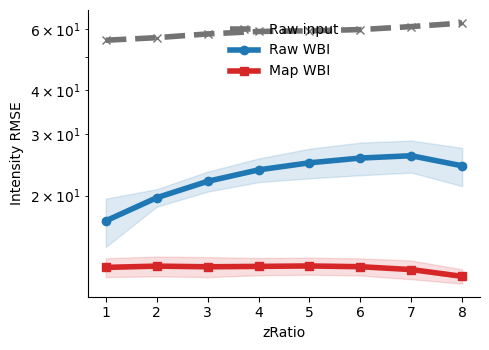

In [5]:
fig, ax = plt.subplots(figsize=(5.0, 3.6))

styles = {
    "raw_input": {"label": "Raw input", "color": "0.45", "marker": "x", "linestyle": "--"},
    "raw_wbi": {"label": "Raw WBI", "color": "#1f77b4", "marker": "o", "linestyle": "-"},
    "map_wbi": {"label": "Map WBI", "color": "#d62728", "marker": "s", "linestyle": "-"},
}

for method, style in styles.items():
    part = summary[summary["method"] == method].sort_values("zRatio")
    x = part["zRatio"].to_numpy()
    y = part["rmse_mean"].to_numpy()
    yerr = part["rmse_std"].fillna(0.0).to_numpy()

    ax.plot(
        x, y,
        label=style["label"],
        color=style["color"],
        marker=style["marker"],
        linestyle=style["linestyle"],
        linewidth=4.0,
        markersize=6,
    )
    if method != "raw_input":
        ax.fill_between(x, y - yerr, y + yerr, color=style["color"], alpha=0.15)

ax.set_xlabel("zRatio")
ax.set_ylabel("Intensity RMSE")
ax.set_yscale("log")
ax.set_xticks(Z_RATIOS)
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()

fig.savefig(RESULT_ROOT / "rmse_vs_zRatio.png", dpi=300)
fig.savefig(RESULT_ROOT / "rmse_vs_zRatio.pdf")
plt.show()

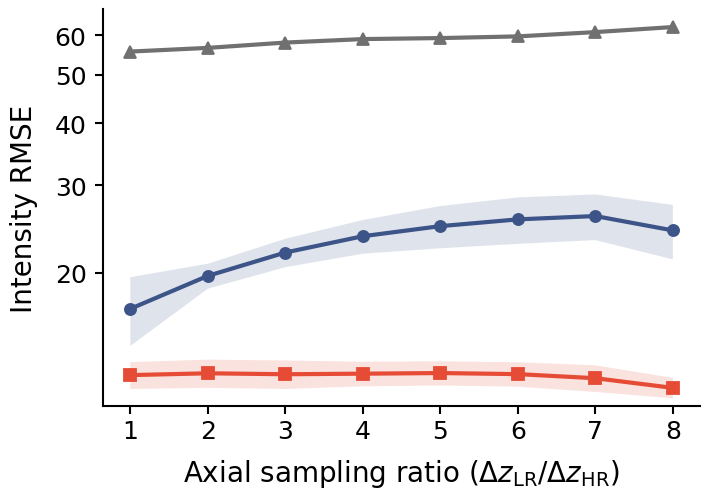

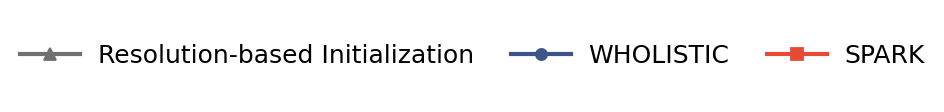

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# ============================================================
# Global style
# ============================================================

plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,

    "axes.linewidth": 1.5,

    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,

    "xtick.major.size": 6,
    "ytick.major.size": 6,
})


# ============================================================
# Main figure
# ============================================================

fig, ax = plt.subplots(figsize=(7.5, 5.4))


# ============================================================
# Plot styles
# ============================================================

styles = {
    "raw_input": {
        "label": "Resolution-based Initialization",
        "color": "#707070",
        "marker": "^",
        "linestyle": "-",
    },

    "raw_wbi": {
        "label": "WHOLISTIC",
        "color": "#3C5488",
        "marker": "o",
        "linestyle": "-",
    },

    "map_wbi": {
        "label": "SPARK",
        "color": "#E64B35",
        "marker": "s",
        "linestyle": "-",
    },
}


# ============================================================
# Plot curves
# ============================================================

for method, style in styles.items():

    part = (
        summary[summary["method"] == method]
        .sort_values("zRatio")
    )

    x = part["zRatio"].to_numpy()
    y = part["rmse_mean"].to_numpy()
    yerr = part["rmse_std"].fillna(0.0).to_numpy()

    # --------------------------------------------------------
    # Mean curve
    # --------------------------------------------------------

    ax.plot(
        x,
        y,

        label=style["label"],

        color=style["color"],

        marker=style["marker"],
        markerfacecolor=style["color"],
        markeredgecolor=style["color"],
        markeredgewidth=1.3,

        linestyle=style["linestyle"],

        linewidth=3.0,
        markersize=8,

        zorder=3,
    )

    # --------------------------------------------------------
    # Error band
    # Raw input: no error band
    # --------------------------------------------------------

    if method != "raw_input":

        lower = y - yerr
        upper = y + yerr

        # Log axis requires positive values
        positive_y = y[y > 0]

        if positive_y.size > 0:
            minimum_positive = np.min(positive_y) * 1e-3
            lower = np.maximum(lower, minimum_positive)

        ax.fill_between(
            x,
            lower,
            upper,

            facecolor=style["color"],
            alpha=0.16,

            # No upper/lower envelope lines
            edgecolor="none",
            linewidth=0,

            zorder=1,
        )


# ============================================================
# Axis labels
# ============================================================

ax.set_xlabel(
    r"Axial sampling ratio ($\Delta z_{\mathrm{LR}}/\Delta z_{\mathrm{HR}}$)",
    labelpad=10,
)

ax.set_ylabel(
    "Intensity RMSE",
    labelpad=12,
)


# ============================================================
# Y axis: logarithmic
# ============================================================

ax.set_yscale("log")


# ============================================================
# Let matplotlib first determine the Y limits
# ============================================================

ax.relim()
ax.autoscale_view()

ymin, ymax = ax.get_ylim()


# ============================================================
# Generate useful decimal ticks manually
#
# Example:
# if Y range = 20–50
#
# show:
# 20, 30, 40, 50
#
# Their POSITIONS are still logarithmic.
# ============================================================

def generate_log_ticks(ymin, ymax):

    ticks = []

    min_exp = int(np.floor(np.log10(ymin))) - 1
    max_exp = int(np.ceil(np.log10(ymax))) + 1

    for exponent in range(min_exp, max_exp + 1):

        scale = 10 ** exponent

        for multiplier in range(1, 10):

            value = multiplier * scale

            if ymin <= value <= ymax:
                ticks.append(value)

    return ticks


y_ticks = generate_log_ticks(ymin, ymax)

ax.yaxis.set_major_locator(
    mticker.FixedLocator(y_ticks)
)


# ============================================================
# Normal decimal labels
# No scientific notation
# ============================================================

def plain_number_formatter(value, pos):

    if value >= 1:

        # Integer-like values:
        # 20 -> "20"
        # 50 -> "50"
        if np.isclose(value, round(value)):
            return f"{int(round(value))}"

        return f"{value:.2f}".rstrip("0").rstrip(".")

    elif value >= 0.1:
        return f"{value:.1f}".rstrip("0").rstrip(".")

    elif value >= 0.01:
        return f"{value:.2f}".rstrip("0").rstrip(".")

    elif value >= 0.001:
        return f"{value:.3f}".rstrip("0").rstrip(".")

    elif value >= 0.0001:
        return f"{value:.4f}".rstrip("0").rstrip(".")

    else:
        return f"{value:.5f}".rstrip("0").rstrip(".")


ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(plain_number_formatter)
)


# ============================================================
# No minor Y ticks
# ============================================================

ax.yaxis.set_minor_locator(
    mticker.NullLocator()
)

ax.yaxis.set_minor_formatter(
    mticker.NullFormatter()
)


# ============================================================
# X axis
# ============================================================

ax.set_xticks(Z_RATIOS)


# ============================================================
# NO grid lines
# ============================================================

ax.grid(False)


# ============================================================
# Spines
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)

ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)


# ============================================================
# Tick style
# ============================================================

ax.tick_params(
    axis="x",
    which="major",

    bottom=True,
    top=False,

    labelbottom=True,

    direction="out",

    length=6,
    width=1.5,
)

ax.tick_params(
    axis="y",
    which="major",

    left=True,
    right=False,

    labelleft=True,
    labelright=False,

    direction="out",

    length=6,
    width=1.5,

    pad=6,
)


# ============================================================
# Legend handles
#
# Do NOT put legend in the main panel
# ============================================================

handles, labels = ax.get_legend_handles_labels()


# ============================================================
# Layout
# ============================================================

fig.tight_layout()


# ============================================================
# Save main figure
# ============================================================

fig.savefig(
    RESULT_ROOT / "rmse_vs_zRatio.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    RESULT_ROOT / "rmse_vs_zRatio.pdf",
    bbox_inches="tight",
)

plt.show()


# ============================================================
# Separate legend figure
# ============================================================

legend_fig, legend_ax = plt.subplots(
    figsize=(6.0, 1.2)
)

legend_ax.axis("off")

legend_ax.legend(
    handles,
    labels,

    loc="center",

    frameon=False,

    ncol=3,

    handlelength=2.4,
    handletextpad=0.7,
    columnspacing=1.5,

    borderaxespad=0.0,
)


# ============================================================
# Save legend
# ============================================================

legend_fig.savefig(
    RESULT_ROOT / "rmse_vs_zRatio_legend.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True,
    pad_inches=0.02,
)

legend_fig.savefig(
    RESULT_ROOT / "rmse_vs_zRatio_legend.pdf",
    bbox_inches="tight",
    transparent=True,
    pad_inches=0.02,
)


# Display legend below main figure
plt.show()

plt.close(legend_fig)

### Later extensions

Additional metrics can be added to the evaluation cells without changing simulation or registration. The clean-reference target and XY crop are isolated in the evaluation stage.